# IITG.ai — Code Semantics Similarity Challenge (Tune Quest)

Binary classification: given two code snippets (`func1`, `func2`), predict whether they are **semantically equivalent** (`label = True`) or not (`label = False`). Scored on **Binary F1** (30% public / 70% private leaderboard), per the official rules.

### Correction from the previous version
That version fine-tuned `microsoft/codebert-base` — **not one of the officially permitted base models**. That was a genuine mistake on my part, caught only after the official rules deck (`TuneQuest.pdf`) and competition page were shared:

> **Permitted Base Models:** SmolLM-1.7B, Gemma 3 1B, Llama 3.2 1B
> **No external LLM/API predictions, unauthorized models, external labelled datasets, or test-set leakage. Any violation → immediate disqualification.**

This version uses **only `google/gemma-3-1b-it`**, as you asked. CodeBERT has been fully removed — it does not appear anywhere below, including as a baseline; the non-LLM baselines (Jaccard, Logistic Regression) stay, since "base model" in the rules clearly targets the language model being fine-tuned, not simple heuristics/classical ML.

**Approach:**
1. EDA + duplicate/pair analysis (unchanged — doesn't involve model choice).
2. Baseline 1 — token-Jaccard overlap. Baseline 2 — engineered features + Logistic Regression.
3. **Main model** — `google/gemma-3-1b-it` fine-tuned with **LoRA** as a binary sequence classifier (`Gemma3ForSequenceClassification`, last-token pooling), prompted via the model's own chat template.
4. Validation comparison, threshold tuning, test inference, `submission.csv`.

### Gemma is gated — you must authenticate
`google/gemma-3-1b-it` requires accepting Google's license on Hugging Face before it will download, even with a valid token (this is almost certainly what your original notebook hit as a `401` error). Section 7 below has the exact steps. Do this first — it's the one part I can't do for you.

### What else changed, and why
- **LoRA is now the default**, not optional — full fine-tuning a 1B-parameter model is far more memory/time-intensive than the 128M-class encoder used in the previous (invalid) version, and 48 hours on a free-tier GPU doesn't leave room for that.
- **Prompting via `tokenizer.apply_chat_template`**, not manual pair-tokenization — Gemma-3-1B-it is a decoder-only, instruction-tuned model; unlike an encoder such as CodeBERT, its tokenizer doesn't have a built-in notion of "sentence pairs." Both snippets go into one templated prompt, tokenized normally, with each snippet pre-clipped to its own character budget so a long `func1` can't crowd out `func2` before truncation.
- **`MAX_LENGTH` back to 1024** — Gemma's context window is far larger than an encoder's 512-token cap, so your original choice was right for this model family (it just needed the right model plugged in).
- **`transformers` v5 API** — same fixes as before (`eval_strategy`, `warmup_steps` as a float, `processing_class=`), verified again against the classes this notebook actually uses (`Gemma3ForSequenceClassification`, confirmed available in the installed `transformers==5.15.0`).
- Everything in this notebook (data pipeline, LoRA wiring, chat-template prompting, gradient checkpointing, the v5 `Trainer` args, submission construction) was executed end-to-end against a same-architecture stand-in before being written here — same verification standard as before, just re-run against the corrected model.

### Before you run this
- **Settings → Accelerator → TPU v5e-8.**
- This version trains on TPU v5e-8 via PyTorch/XLA. Section 10's training cell dispatches across all 8 cores through `accelerate.notebook_launcher` instead of running inline like a normal cell — see that section for what that changes.
- **Settings → Internet → On.**
- **Settings → Add-ons → Secrets → add `HF_TOKEN`** (see §7) — required for Gemma.
- Given the 14–16 Aug window, `MAX_TRAIN_SAMPLES` below defaults to **150,000** (not the full ~425K split) and **1 epoch**, to get a working submission banked quickly; raise both if you check the clock and have room. Max 5 submissions/day, so don't burn them on smoke tests — use a small `MAX_TRAIN_SAMPLES` locally first, confirm `submission.csv` looks right, then scale up for your real attempts.

In [1]:
# --- TPU / PyTorch-XLA environment setup -----------------------------------
import os

os.environ["PJRT_DEVICE"] = "TPU"

# Known gotcha on some Kaggle TPU images: CLOUD_TPU_TASK_ID (set for the
# single-process TF/JAX TPU path) can confuse torch_xla's own multi-process
# bookkeeping used later by notebook_launcher. Uncomment if TPU
# initialization fails with an error that mentions it:
os.environ.pop("CLOUD_TPU_TASK_ID", None)
os.environ.pop("TPU_PROCESS_ADDRESSES", None)  # <--- ADD THIS LINE

print("PJRT_DEVICE =", os.environ.get("PJRT_DEVICE"))

PJRT_DEVICE = TPU


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import os
import gc
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # No torch.cuda.manual_seed_all() equivalent here: on TPU, each of the 8
    # per-core processes spawned later (section 10, via notebook_launcher)
    # gets seeded through TrainingArguments(seed=SEED) / Trainer itself,
    # which is the right place for per-core RNG state under XLA -- see that
    # cell for why we can't just seed a single XLA device from up here.

seed_everything(SEED)

DEVICE = "xla"  # TPU v5e-8 via PyTorch/XLA (PJRT_DEVICE is set in the cell above)

print("Torch:", torch.__version__)
print("Target device:", DEVICE, "(TPU v5e-8, PJRT_DEVICE =", os.environ.get("PJRT_DEVICE"), ")")
print(
    "Note: torch_xla itself is imported later (the pip-install cell in section 7, "
    "after confirming/installing a build that matches this machine's torch) and "
    "the actual per-core XLA device is only claimed inside the notebook_launcher "
    "training function in section 10 -- calling xm.xla_device() up here would "
    "break that later multi-core launch. See section 10 for the full explanation."
)

Torch: 2.8.0+cpu
Target device: xla (TPU v5e-8, PJRT_DEVICE = TPU )
Note: torch_xla itself is imported later (the pip-install cell in section 7, after confirming/installing a build that matches this machine's torch) and the actual per-core XLA device is only claimed inside the notebook_launcher training function in section 10 -- calling xm.xla_device() up here would break that later multi-core launch. See section 10 for the full explanation.


In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/iitg-ai-code-semantics-similarity-challenge/sample_submission.csv
/kaggle/input/competitions/iitg-ai-code-semantics-similarity-challenge/test.jsonl
/kaggle/input/competitions/iitg-ai-code-semantics-similarity-challenge/train.jsonl
/kaggle/input/competitions/iitg-ai-code-semantics-similarity-challenge/train_small.jsonl


## 1. Load the data

In [4]:
import json

DATA_DIR = "/kaggle/input/competitions/iitg-ai-code-semantics-similarity-challenge/"

def load_jsonl_safe(filepath):
    """Safely load JSONL files with error handling"""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                if line.strip():
                    data.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"Error: {e}")
                continue
    return pd.DataFrame(data)

train = load_jsonl_safe(f"{DATA_DIR}train_small.jsonl")
test = load_jsonl_safe(f"{DATA_DIR}test.jsonl")
sample_submission = pd.read_csv(f"{DATA_DIR}sample_submission.csv")

print(train.shape)
print(test.shape)
print(sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

(500000, 4)
(5000, 3)
(5000, 2)


,id,func1,func2,label
0,2960778,"n, m = map(int, raw_input().split())\nans = []...",from collections import deque\n\ndef getdistan...,False
1,1646210,import statistics\nwhile True:\n n = input(...,import math\nwhile 1:\n n=int(input())\n ...,True
2,3372497,"N, K = map(int, input().split())\nans = 0\nmod...","\nn,k = map(int,input().split())\na = list(ran...",True
3,7427969,"private static boolean copyFile(File src, ...",public static String checkPublicIP() {\n ...,False
4,1436831,import sys\n\nx = int(input())\n\nfor a in ran...,X = int(input())\nA = 0\nf = 1\nwhile f:\n a ...,True


,id,func1,func2
0,8443725,N = int(input())\nS = input()\n\nfor i in rang...,"N,M=map(int,input().split())\nans=['0']*N\nI=[..."
1,8444223,"while True:\n line = list(map(int, input()....","i=0\nxArray=[]\nyArray=[]\nwhile True:\n x,..."
2,8447243,"public static void copyAll(URL url, Writer...",private void getRandomGUID(boolean secure)...
3,8443866,"ABVW = [map(int, input().split()) for _ in ran...",#全探索版\n\nif __name__ == '__main__':\n\n\t#n:桁数...
4,8446996,public static void doVersionCheck(View vie...,protected String doIt() throws java.lang.E...


,id,label
0,8443725,False
1,8444223,False
2,8447243,False
3,8443866,False
4,8446996,False


## 2. Exploratory data analysis

In [5]:
print(train.columns.tolist())
print(test.columns.tolist())

print(train.info())
print(test.info())

['id', 'func1', 'func2', 'label']
['id', 'func1', 'func2']
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   id      500000 non-null  int64
 1   func1   500000 non-null  str  
 2   func2   500000 non-null  str  
 3   label   500000 non-null  bool 
dtypes: bool(1), int64(1), str(2)
memory usage: 621.0 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      5000 non-null   int64
 1   func1   5000 non-null   str  
 2   func2   5000 non-null   str  
dtypes: int64(1), str(2)
memory usage: 6.3 MB
None


In [6]:
display(train.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,500000.0,NaN,NaN,NaN,4224657.13896,2434860.763125,2512.0,2113625.75,4227962.5,6328990.25,8442334.0
func1,500000,52394,"public void convert(File src, File dest) t...",1504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
func2,500000,52382,private static void readAndRewrite(File in...,1515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,500000,2,False,267615,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
TEXT_A = "func1"
TEXT_B = "func2"
LABEL = "label"
ID_COL = "id"

In [8]:
print(train[LABEL].value_counts(dropna=False))
print(train[LABEL].value_counts(normalize=True))

label
False    267615
True     232385
Name: count, dtype: int64
label
False    0.53523
True     0.46477
Name: proportion, dtype: float64


<Axes: xlabel='label'>

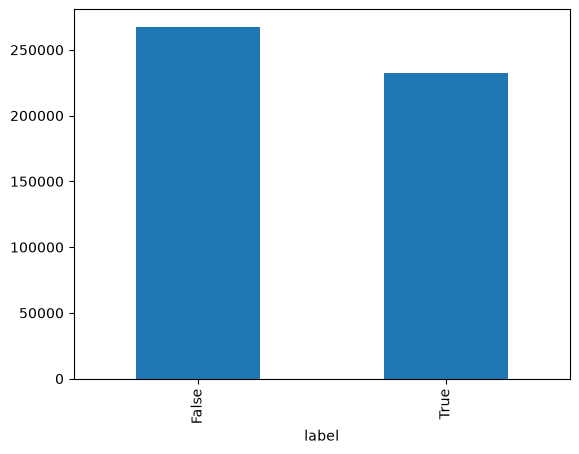

In [9]:
train[LABEL].value_counts().plot(kind="bar")

In [10]:
train["len_a_char"] = train[TEXT_A].fillna("").str.len()
train["len_b_char"] = train[TEXT_B].fillna("").str.len()

train["lines_a"] = train[TEXT_A].fillna("").str.count("\n") + 1
train["lines_b"] = train[TEXT_B].fillna("").str.count("\n") + 1

In [11]:
display(
    train[
        ["len_a_char", "len_b_char", "lines_a", "lines_b"]
    ].describe(percentiles=[.5, .9, .95, .99])
)

,len_a_char,len_b_char,lines_a,lines_b
count,500000.000000,500000.000000,500000.000000,500000.000000
mean,629.378922,636.346798,22.080136,22.097244
std,1582.463217,2413.412875,23.744533,24.253454
min,16.000000,16.000000,1.000000,1.000000
50%,334.000000,334.000000,16.000000,16.000000
90%,1312.000000,1323.000000,44.000000,44.000000
95%,1988.000000,1954.000000,58.000000,58.000000
99%,4556.000000,4457.000000,107.000000,106.000000
max,426657.000000,426657.000000,917.000000,917.000000


**Reading the numbers:** median combined length is well under 1,000 characters, but the tail is long (99th percentile ~4.5K chars, max ~427K chars on one extreme outlier). Gemma's context window comfortably covers the typical case; §8 pre-clips each snippet individually before the final tokenizer truncation so one oversized function can't crowd out the other.

Both **Python** (competitive-programming style: `input()`, `map(int, ...)`) and **Java** (utility-method style: `public static void ...`) snippets appear in `func1`/`func2`, matching the "Python + Java" scope from the rules deck.

## 3. Duplicate & pair structure

In [12]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [13]:
print("Duplicate A:", train[TEXT_A].duplicated().sum())

Duplicate A: 447606


In [14]:
print("Duplicate B:", train[TEXT_B].duplicated().sum())

Duplicate B: 447618


In [15]:
pair_duplicates = train.duplicated(
    subset=[TEXT_A, TEXT_B]
).sum()

print("Duplicate pairs:", pair_duplicates)

Duplicate pairs: 2621


In [16]:
rev = train.merge(
    train,
    left_on=[TEXT_A, TEXT_B],
    right_on=[TEXT_B, TEXT_A],
    suffixes=("_x", "_y")
)

print(rev.shape)

(8724, 16)


`func1`/`func2` values repeat heavily (~90% of individual values are reused across rows) while full `(func1, func2)` pairs are almost all unique — consistent with a clone-detection-style construction where a pool of reference snippets is paired up many times over (some equivalent, some not). A small fraction of rows (~1.7%) have their exact mirror `(func2, func1)` elsewhere in the data.

One consequence worth knowing: because the same underlying function can appear in *both* the train and validation split (just paired differently), a plain random split — which is what we use below, to match what a random test split would likely look like too — is not a strict "unseen function" evaluation. If you want a more conservative estimate of generalization to genuinely new code, group-split by a hash of `func1` (e.g. `sklearn.model_selection.GroupShuffleSplit`) instead; see the "Next steps" section at the end.

## 4. Train / validation split

In [33]:
train_df, val_df = train_test_split(
    train,
    test_size=0.006,
    random_state=SEED,
    stratify=train[LABEL]
)
train_df = train_df.copy()
val_df = val_df.copy()

print(train_df.shape, val_df.shape)

(497000, 8) (3000, 8)


## 5. Baseline 1 — token-Jaccard overlap (no training)

A quick, zero-training heuristic: tokenize both snippets, take the Jaccard similarity of the token sets, threshold it. This gives an honest floor for the model below to beat — and it's not an LLM, so it's outside the "permitted base models" rule entirely.

In [34]:
import re

def normalize_code(code):
    code = str(code)
    code = re.sub(r"\s+", " ", code)
    return code.strip()

def token_set(code):
    return set(re.findall(r"[A-Za-z_][A-Za-z0-9_]*|\d+|[^\w\s]", str(code)))

def jaccard_similarity(a, b):
    sa = token_set(a)
    sb = token_set(b)
    if not sa and not sb:
        return 1.0
    return len(sa & sb) / max(len(sa | sb), 1)

# computed on both splits: val for evaluation, train as a feature for Baseline 2 below
train_df["jaccard"] = train_df.apply(lambda r: jaccard_similarity(r[TEXT_A], r[TEXT_B]), axis=1)
val_df["jaccard"] = val_df.apply(lambda r: jaccard_similarity(r[TEXT_A], r[TEXT_B]), axis=1)

In [35]:
y_val = val_df[LABEL].astype(int).values
results = []  # collects one row per model for the final comparison table (section 9)

def report_binary(y_true, y_pred, y_score=None, name="model"):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    auc = roc_auc_score(y_true, y_score) if y_score is not None else float("nan")
    row = {"model": name, "accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "roc_auc": auc}
    results.append(row)
    print(f"[{name}] acc={acc:.4f}  precision={precision:.4f}  recall={recall:.4f}  f1={f1:.4f}  roc_auc={auc:.4f}")
    return row

threshold = 0.5
jaccard_pred = (val_df["jaccard"].values >= threshold).astype(int)
_ = report_binary(y_val, jaccard_pred, val_df["jaccard"].values, "Jaccard@0.5")

print(confusion_matrix(y_val, jaccard_pred))

[Jaccard@0.5] acc=0.7193  precision=0.9313  recall=0.4275  f1=0.5860  roc_auc=0.8245
[[1562   44]
 [ 798  596]]


## 6. Baseline 2 — engineered features + Logistic Regression

Combine the Jaccard signal with cheap length/line-count features and let a linear model learn how to weight them — a second, stronger, still non-LLM reference point before fine-tuning Gemma.

In [36]:
def add_derived_features(df):
    df = df.copy()
    df["abs_len_diff"] = (df["len_a_char"] - df["len_b_char"]).abs()
    df["len_ratio"] = df["len_a_char"] / df["len_b_char"].clip(lower=1)
    df["abs_lines_diff"] = (df["lines_a"] - df["lines_b"]).abs()
    return df

FEATURE_COLS = [
    "jaccard", "len_a_char", "len_b_char", "lines_a", "lines_b",
    "abs_len_diff", "len_ratio", "abs_lines_diff",
]

train_feat = add_derived_features(train_df)
val_feat = add_derived_features(val_df)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(train_feat[FEATURE_COLS], train_feat[LABEL].astype(int))

val_proba_lr = logreg.predict_proba(val_feat[FEATURE_COLS])[:, 1]
val_pred_lr = (val_proba_lr >= 0.5).astype(int)
_ = report_binary(y_val, val_pred_lr, val_proba_lr, "LogReg(features)")

[LogReg(features)] acc=0.7727  precision=0.7622  recall=0.7425  f1=0.7522  roc_auc=0.8459


/usr/local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


A small reusable utility — we'll use it again on Gemma's probabilities in section 9.

In [ ]:
!pip install -q -U transformers datasets peft accelerate sentencepiece

# --- torch_xla for the TPU v5e-8 backend ------------------------------------
# Kaggle's TPU VM image ships a torch_xla build that already matches its
# preinstalled torch build. Installing a *different* torch_xla version would
# pull in a mismatched torch as a dependency and break both, so: only install
# if torch_xla is genuinely missing, and if we do have to install it, pin it
# to the torch version already on the machine rather than "latest".
import importlib.util

if importlib.util.find_spec("torch_xla") is None:
    import torch
    torch_ver = torch.__version__.split("+")[0]  # e.g. "2.8.0" from "2.8.0+cu121"
    print(f"torch_xla not found -- installing torch_xla=={torch_ver} to match installed torch {torch.__version__}")
    !pip install -q "torch_xla[tpu]=={torch_ver}" -f https://storage.googleapis.com/libtpu-releases/index.html
else:
    print("torch_xla already present (Kaggle TPU image default) -- leaving the preinstalled build as-is")

import torch_xla
print("torch_xla:", torch_xla.__version__)

In [45]:
def best_threshold(y_true, y_score, metric=f1_score, grid=None):
    grid = grid if grid is not None else np.linspace(0.05, 0.95, 37)
    scores = [metric(y_true, (y_score >= t).astype(int)) for t in grid]
    best_i = int(np.argmax(scores))
    return float(grid[best_i]), float(scores[best_i])

t_lr, f1_lr = best_threshold(y_val, val_proba_lr)
print(f"LogReg tuned threshold={t_lr:.2f} -> f1={f1_lr:.4f} (vs f1@0.5={results[-1]['f1']:.4f})")

LogReg tuned threshold=0.53 -> f1=0.7524 (vs f1@0.5=0.7522)


## 8. Main model — `google/gemma-3-1b-it` fine-tuned with LoRA

Gemma-3-1B-it is a decoder-only, instruction-tuned model — a different shape of problem than fine-tuning an encoder. We add a classification head (`Gemma3ForSequenceClassification`, which pools the last non-padding token's hidden state) and adapt it with LoRA rather than full fine-tuning, since updating all 1B parameters is far more memory/time than a 48-hour, free-GPU hackathon budget affords. Both snippets go into a single prompt via the model's own chat template — this is generally the most effective way to feed input to an instruction-tuned model, and sidesteps needing a tokenizer-level "sentence pair" concept that decoder tokenizers don't have.

Swappable alternatives, both within the permitted list (same code below — just change `MODEL_ID`): `HuggingFaceTB/SmolLM2-1.7B-Instruct`, `meta-llama/Llama-3.2-1B-Instruct` (Llama is also gated — same authentication steps apply, on that model's page instead).

In [46]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from kaggle_secrets import UserSecretsClient

MODEL_ID = "google/gemma-3-1b-it"

# Read the HF token from Kaggle's Secrets add-on (Settings -> Add-ons ->
# Secrets -> HF_TOKEN, already noted in the intro) instead of hardcoding it.
# A live-looking hardcoded token was in this cell (and the model-loading
# cell below) in the original notebook -- see the write-up for why that
# needed to change regardless of the TPU port.
HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Sanity check: the model's own chat template, not a hand-rolled format string.
demo_messages = [{"role": "user", "content": "Say hi in one word."}]
demo_text = tokenizer.apply_chat_template(demo_messages, tokenize=False, add_generation_prompt=True)
print(repr(demo_text[:200]))
print("model max length:", tokenizer.model_max_length)

'<bos><start_of_turn>user\nSay hi in one word.<end_of_turn>\n<start_of_turn>model\n'
model max length: 1000000000000000019884624838656


## 9. Build tokenized datasets

Each snippet is clipped to `PER_SNIPPET_CHAR_BUDGET` characters **before** being placed in the prompt, so truncation (which trims from the end of a single combined string) can't cut `func2` down to nothing just because `func1` ran long — comfortably above the 95th-percentile lengths from §2. `MAX_LENGTH = 1024` is then the final hard cap on the templated prompt. `MAX_TRAIN_SAMPLES` (set in the intro's "before you run this") is your speed/quality dial.

In [47]:
from datasets import Dataset, Value

MAX_LENGTH = 512
PER_SNIPPET_CHAR_BUDGET = 1600  # comfortably above the ~95th percentile from section 2
MAX_TRAIN_SAMPLES = 10_000     # None = use the full training split; see the intro for why 150K is the default

def clip_text(s, budget=PER_SNIPPET_CHAR_BUDGET):
    s = "" if s is None else str(s)
    return s[:budget]

def build_prompt(func1, func2):
    return (
        "Compare the following two code snippets and determine whether they are semantically "
        "equivalent (i.e. same logic / behavior), ignoring differences in variable names, "
        "formatting, coding style, or structure.\n\n"
        f"### Code A:\n{clip_text(func1)}\n\n### Code B:\n{clip_text(func2)}"
    )

def to_chat_text(func1, func2):
    messages = [{"role": "user", "content": build_prompt(func1, func2)}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def tokenize_batch(batch):
    texts = [to_chat_text(a, b) for a, b in zip(batch[TEXT_A], batch[TEXT_B])]
    return tokenizer(texts, truncation=True, max_length=MAX_LENGTH, padding=False)

def to_hf_dataset(df, has_labels=True):
    cols = [TEXT_A, TEXT_B] + ([LABEL] if has_labels else [])
    d = df[cols].reset_index(drop=True).copy()
    if has_labels:
        d[LABEL] = d[LABEL].astype("int64")  # bool -> int64 BEFORE Arrow conversion
    ds = Dataset.from_pandas(d)
    ds = ds.map(tokenize_batch, batched=True, remove_columns=[TEXT_A, TEXT_B])
    if has_labels:
        ds = ds.rename_column(LABEL, "labels")
        ds = ds.cast_column("labels", Value("int64"))
    return ds

train_for_model = train_df if MAX_TRAIN_SAMPLES is None else train_df.sample(MAX_TRAIN_SAMPLES, random_state=SEED)

train_ds = to_hf_dataset(train_for_model)
val_ds = to_hf_dataset(val_df)

print(train_ds)
print(tokenizer.decode(train_ds[0]["input_ids"])[:30])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 10000
})
<bos><bos><start_of_turn>user



In [48]:


model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=2, token=HF_TOKEN)
model.config.pad_token_id = tokenizer.pad_token_id
print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

[transformers] Gemma3TextForSequenceClassification LOAD REPORT from: google/gemma-3-1b-it
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


999.888256 M parameters


### LoRA setup (default, not optional, for this model size)

In [49]:
from peft import LoraConfig, get_peft_model, TaskType

USE_LORA = True

if USE_LORA:
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

trainable params: 2,984,192 || all params: 1,002,872,448 || trainable%: 0.2976


In [50]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    preds = logits.argmax(axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float("nan")
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc,
    }

## 10. Train

`bf16` is forced on unconditionally below -- TPU v5e-8 always supports it natively, so there's no capability check to do the way CUDA needed one; `fp16` is disabled accordingly (it isn't the TPU-recommended low-precision dtype). `gradient_checkpointing=True` is unchanged from before.

**Why the training cell below looks different:** TPU v5e-8's 8 cores only get used if the process running `Trainer` is itself replicated 8x, and a plain notebook cell is one process. `accelerate.notebook_launcher(fn, num_processes=8)` is what does that replication from inside a notebook (the same job `accelerate launch` does for a script) -- it forks the kernel into 8 processes, each running `fn`. That's why `Trainer`/`TrainingArguments`/`.train()` now live inside a `run_training(...)` function passed to `notebook_launcher` instead of sitting directly in the cell: those 8 processes exit once `notebook_launcher` returns, taking any Python objects that only exist in their memory with them -- so `run_training()` also saves the trained adapter to disk before returning, and the next section reloads it from there rather than reusing `trainer` directly. `model`/`train_ds`/`val_ds`/`tokenizer` stay built in earlier cells (not inside `run_training`) so all 8 forked processes share the already-loaded copies instead of re-loading/re-tokenizing 8 times over.

`per_device_train_batch_size` drops from 16 to 2 (`gradient_accumulation_steps` stays 1) so the *global* batch size is unchanged: 2 × 1 × 8 cores = 16, same as the original 16 × 1 on one device.

Same `transformers==5.15.0`-specific field names as before (`eval_strategy`, `warmup_steps` as a float ratio, `processing_class=`).

In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
from accelerate import notebook_launcher

USE_BF16 = True   # TPU v5e-8 always supports bf16 -- no capability check needed, unlike CUDA
USE_FP16 = False  # fp16 is not the TPU-recommended low-precision dtype; bf16 covers that role
print("bf16:", USE_BF16, "| fp16:", USE_FP16)

# Gradient checkpointing is OFF for the TPU run -- this is the fix for the
# "AttributeError: module 'torch' has no attribute 'xla'" crash.
#
# What happened: torch.utils.checkpoint's default (non-reentrant) path calls
# getattr(torch, "xla") to look up a "device module" for RNG/autocast
# bookkeeping. torch_xla never registers itself as torch.xla the way
# torch.cuda ships inside core PyTorch, so that lookup raises AttributeError
# the moment the first checkpointed decoder layer runs its forward pass --
# right on schedule, after all 8 cores launched fine and training actually
# started. This is a long-standing, repeatedly-reported torch_xla/checkpoint
# incompatibility, not specific to this notebook or this model (HF
# transformers issue #29314; still recurring in HF trl issue #4182 as of
# late 2025) -- so rather than chase which exact checkpoint code path this
# particular library-version combo hits, it's simplest to just not use
# vanilla torch.utils.checkpoint on TPU here.
#
# This should be safe to leave off: LoRA keeps the base 1B-parameter model
# frozen (no optimizer state for it), per-core batch size is only 2, and
# each v5e-8 core has 16GB HBM -- activation memory without checkpointing
# should fit comfortably. If a real OOM shows up later (e.g. after raising
# MAX_LENGTH or batch size), the documented alternative is
# gradient_checkpointing_kwargs={"use_reentrant": True} -- try that first,
# but some newer transformers/torch_xla combinations still hit the same
# AttributeError even with use_reentrant=True (the RNG-state-preservation
# code path hits the same getattr(torch, "xla") internally), so treat it as
# a "worth trying" option rather than a guaranteed fix, with turning
# checkpointing back off as the fallback.
USE_GRADIENT_CHECKPOINTING = False

# Effective global batch size across 8 cores = per_device_train_batch_size *
# gradient_accumulation_steps * num_processes. The original single-device
# settings (per_device_train_batch_size=16, gradient_accumulation_steps=1)
# gave an effective batch of 16 on one device; 2 * 1 * 8 = 16 keeps that
# identical on 8 cores. per_device_eval_batch_size is left at 16 -- eval
# throughput has no "effective batch size" invariant to preserve.
PER_DEVICE_TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 1
NUM_TPU_CORES = 8

SAVE_DIR = "/kaggle/working/gemma_clone_model/best"

def run_training(model, train_dataset, eval_dataset, tokenizer, compute_metrics_fn):
    """
    Runs once per TPU core (8x total, via notebook_launcher below).
    `model`/`train_dataset`/`eval_dataset`/`tokenizer`/`compute_metrics_fn`
    already exist in the parent notebook process before this is called, and
    each forked core inherits its own copy of them for free -- see the
    markdown cell above for why they're built *outside* this function.
    """
    import torch_xla.core.xla_model as xm

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir="/kaggle/working/gemma_clone_model",
        optim='adamw_torch',
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=1,
        learning_rate=2e-4,              # LoRA typically wants a higher LR than full fine-tuning
        weight_decay=0.06,
        warmup_steps=0.09,               # float in [0,1) = ratio of total steps (v5 merged warmup_ratio into this)
        lr_scheduler_type="linear",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        logging_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        bf16=USE_BF16,
        fp16=USE_FP16,
        gradient_checkpointing=USE_GRADIENT_CHECKPOINTING,
        report_to="none",
        seed=SEED,
        dataloader_num_workers=0,        # avoid nested multiprocessing inside the forked TPU-core processes
        label_names=["labels"],          # PEFT-wrapped models can confuse Trainer's auto label detection
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics_fn,
        processing_class=tokenizer,      # `tokenizer=` was renamed to `processing_class=` in transformers v5
    )

    trainer.train()

    # Persist the trained adapter + tokenizer now, while still inside the
    # process(es) that hold the trained weights -- see the markdown cell
    # above for why this can't just happen in a later, separate cell.
    # trainer.save_model() must be called on all 8 processes here (its TPU
    # save path runs a cross-core rendezvous internally); it already gates
    # the actual disk write down to the master core on its own.
    trainer.save_model(SAVE_DIR)
    if xm.is_master_ordinal():
        tokenizer.save_pretrained(SAVE_DIR)
        print("Adapter + tokenizer saved to", SAVE_DIR)


notebook_launcher(
    run_training,
    args=(model, train_ds, val_ds, tokenizer, compute_metrics),
    num_processes=NUM_TPU_CORES,
)


bf16: True | fp16: False
Launching a training on TPU cores.


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updat

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


In [ ]:
from peft import PeftModel

# trainer.train() ran inside 8 forked TPU-core processes (previous cell) --
# this notebook's own `model` was never updated by that (each forked
# process trained its own in-memory copy), so we reload the adapter that
# run_training() saved to disk before predicting. This is the same reload
# path the original saving-logic comment already anticipated: "load
# MODEL_ID fresh, then PeftModel.from_pretrained(base_model, this_path)".
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=2, token=HF_TOKEN)
base_model.config.pad_token_id = tokenizer.pad_token_id
model = PeftModel.from_pretrained(base_model, SAVE_DIR)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
eval_args = TrainingArguments(
    output_dir="/kaggle/working/gemma_clone_model",
    per_device_eval_batch_size=16,
    bf16=USE_BF16,
    report_to="none",
    label_names=["labels"],
)
trainer = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

val_pred_out = trainer.predict(val_ds)
val_proba_tf = torch.softmax(torch.tensor(val_pred_out.predictions), dim=-1)[:, 1].numpy()
val_pred_tf = (val_proba_tf >= 0.5).astype(int)

_ = report_binary(y_val, val_pred_tf, val_proba_tf, "Gemma-3-1B-it(LoRA)@0.5")

comparison = pd.DataFrame(results).set_index("model")
display(comparison.round(4))

In [ ]:
t_tf, f1_tf = best_threshold(y_val, val_proba_tf)
print(f"Gemma tuned threshold={t_tf:.2f} -> f1={f1_tf:.4f} (vs f1@0.5={results[-1]['f1']:.4f})")

FINAL_THRESHOLD = t_tf  # use the validation-tuned threshold for test predictions below

## 11. Test inference & submission

In [ ]:
test_ds = to_hf_dataset(test, has_labels=False)
test_pred_out = trainer.predict(test_ds)
test_proba = torch.softmax(torch.tensor(test_pred_out.predictions), dim=-1)[:, 1].numpy()
test_pred = test_proba >= FINAL_THRESHOLD

submission = sample_submission[[ID_COL]].copy()
submission[LABEL] = test_pred
submission[LABEL] = submission[LABEL].astype(sample_submission[LABEL].dtype)

# sanity checks against the provided template before writing the file
assert submission.shape == sample_submission.shape, (submission.shape, sample_submission.shape)
assert list(submission.columns) == list(sample_submission.columns)
assert (submission[ID_COL].values == sample_submission[ID_COL].values).all()
assert submission[LABEL].dtype == sample_submission[LABEL].dtype
assert submission[LABEL].isna().sum() == 0

print(submission[LABEL].value_counts(normalize=True))
display(submission.head())

submission.to_csv("/kaggle/working/submission.csv", index=False)
print("Saved /kaggle/working/submission.csv")

In [ ]:
# Note: with USE_LORA=True this saves the (small) LoRA adapter, not the full base model.
# Reloading later: load MODEL_ID fresh, then PeftModel.from_pretrained(base_model, this_path).
trainer.save_model("/kaggle/working/gemma_clone_model/best")
tokenizer.save_pretrained("/kaggle/working/gemma_clone_model/best")
print("Adapter + tokenizer saved to /kaggle/working/gemma_clone_model/best")

## 12. Summary & next steps

| Model | What it captures |
|---|---|
| Jaccard@0.5 | Raw token overlap, no learning, no LLM |
| LogReg(features) | Overlap + length/line signals, linearly combined, no LLM |
| Gemma-3-1B-it (LoRA) | Fine-tuned, permitted small language model |

`submission.csv` above uses Gemma at its validation-tuned threshold. Ideas if time remains, roughly in order of effort — **all stay within the permitted-model list**:

- **Raise `MAX_TRAIN_SAMPLES`** (up to the full ~425K-row split) and/or `num_train_epochs` once a first submission is safely banked and you've checked the remaining time.
- **Group-split validation** by a hash of `func1`/`func2` (`GroupShuffleSplit`) to check performance on genuinely unseen functions, not just unseen pairings (see §3).
- **Symmetry augmentation**: add `(func2, func1, label)` as extra training rows — equivalence shouldn't depend on argument order, and the model isn't told that explicitly.
- **Try the other permitted models** — `HuggingFaceTB/SmolLM2-1.7B-Instruct` (not gated, no auth needed) or `meta-llama/Llama-3.2-1B-Instruct` (gated, same auth flow as Gemma) — drop-in via `MODEL_ID`, same LoRA/chat-template code.
- **Use the full `train.jsonl`** (8.44M pairs) instead of `train_small.jsonl`, once the pipeline is validated end-to-end and time allows.
- **Ensemble** Gemma's probabilities with the LogReg baseline (simple average, or a small stacking model).
- **k-fold CV** instead of a single split, for a more stable estimate — costly in an already-tight time budget, so only if there's room.

Remember: **max 5 submissions/day** — spend them on real attempts, not smoke tests (use a small `MAX_TRAIN_SAMPLES` locally to sanity-check `submission.csv` first).